# K-Protoypes

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
import joblib

## Cargar datos

In [12]:
df = pd.read_csv("../data/processed/olist_engineering.csv")
df_scaled = pd.read_csv("../data/processed/olist_scaled.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  115878 non-null  str    
 1   customer_id               115878 non-null  str    
 2   order_purchase_timestamp  115878 non-null  str    
 3   customer_unique_id        115878 non-null  str    
 4   order_item_id             115878 non-null  float64
 5   product_category_name     115878 non-null  str    
 6   payment_value             115878 non-null  float64
 7   month                     115878 non-null  int64  
 8   day_of_week               115878 non-null  int64  
 9   hour                      115878 non-null  int64  
dtypes: float64(2), int64(3), str(5)
memory usage: 8.8 MB


In [13]:
df.head()

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name,payment_value,month,day_of_week,hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.12,10,0,10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,2.00,10,0,10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.59,10,0,10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,1.0,perfumery,141.46,7,1,20
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,1.0,auto,179.12,8,2,8


In [14]:
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   payment_value          115878 non-null  float64
 1   month                  115878 non-null  float64
 2   hour                   115878 non-null  float64
 3   day_of_week            115878 non-null  float64
 4   product_category_name  115878 non-null  str    
dtypes: float64(4), str(1)
memory usage: 4.4 MB


In [15]:
df_scaled[["payment_value", "month", "hour", "day_of_week"]] = df_scaled[["payment_value", "month", "hour", "day_of_week"]].astype("float32")
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   payment_value          115878 non-null  float32
 1   month                  115878 non-null  float32
 2   hour                   115878 non-null  float32
 3   day_of_week            115878 non-null  float32
 4   product_category_name  115878 non-null  str    
dtypes: float32(4), str(1)
memory usage: 2.7 MB


### KPrototypes Clustering

In [16]:
model = KPrototypes(n_clusters=4, init="cao", n_init=1, verbose=1, max_iter=100, random_state=42)

clusters = model.fit_predict(df_scaled.values, categorical=[4])

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 37896, ncost: 355951.676866708
Run: 1, iteration: 2/100, moves: 16169, ncost: 334996.23404971784
Run: 1, iteration: 3/100, moves: 6882, ncost: 328666.19118308637
Run: 1, iteration: 4/100, moves: 3413, ncost: 327364.45747115137
Run: 1, iteration: 5/100, moves: 1797, ncost: 327041.9218612754
Run: 1, iteration: 6/100, moves: 664, ncost: 326981.54492810887
Run: 1, iteration: 7/100, moves: 390, ncost: 326963.72928710293
Run: 1, iteration: 8/100, moves: 107, ncost: 326961.6788373319
Run: 1, iteration: 9/100, moves: 233, ncost: 326956.4247916242
Run: 1, iteration: 10/100, moves: 196, ncost: 326952.6290292042
Run: 1, iteration: 11/100, moves: 256, ncost: 326949.8609890717
Run: 1, iteration: 12/100, moves: 70, ncost: 326949.58761640853
Run: 1, iteration: 13/100, moves: 37, ncost: 326949.2555004742
Run: 1, iteration: 14/100, moves: 24, ncost: 326949.155903629
Run: 1, iteration: 15/100

In [17]:
pd.Series(clusters).value_counts()

3    40963
1    38841
2    33176
0     2898
Name: count, dtype: int64

In [18]:
df["cluster"] = clusters
df

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name,payment_value,month,day_of_week,hour,cluster
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.12,10,0,10,1
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,2.00,10,0,10,1
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.59,10,0,10,1
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,1.0,perfumery,141.46,7,1,20,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,1.0,auto,179.12,8,2,8,2
...,...,...,...,...,...,...,...,...,...,...,...
115873,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,da62f9e57a76d978d02ab5362c509660,1.0,baby,195.00,2,1,12,2
115874,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,737520a9aad80b3fbbdad19b66b37b30,1.0,home_appliances_2,271.01,8,6,14,1
115875,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,1.0,computers_accessories,441.16,1,0,21,3
115876,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,2.0,computers_accessories,441.16,1,0,21,3


In [19]:
df_scaled["cluster"] = clusters
df_scaled

,payment_value,month,hour,day_of_week,product_category_name,cluster
0,-0.577736,1.230778,-0.894707,-1.399822,housewares,1
1,-0.637860,1.230778,-0.894707,-1.399822,housewares,1
2,-0.575983,1.230778,-0.894707,-1.399822,housewares,1
3,-0.117700,0.300016,0.983385,-0.889928,perfumery,1
4,0.022764,0.610270,-1.270326,-0.380034,auto,2
...,...,...,...,...,...,...
115873,0.081994,-1.251255,-0.519089,-0.889928,baby,2
115874,0.365497,0.610270,-0.143470,1.659544,home_appliances_2,1
115875,1.000125,-1.561509,1.171194,-1.399822,computers_accessories,3
115876,1.000125,-1.561509,1.171194,-1.399822,computers_accessories,3


In [20]:
df_customer_profile = df.groupby("cluster").agg({
    'payment_value': 'mean',
    'month': 'mean',
    'day_of_week': 'mean',
    'hour': 'mean',
    'product_category_name': lambda x: x.value_counts().head(3).index.to_list()
    })

df_customer_profile["customers_count"] = df["cluster"].value_counts()
df_customer_profile

,payment_value,month,day_of_week,hour,product_category_name,customers_count
cluster,,,,,,
0,1336.667157,6.069013,2.547274,14.475500,"[computers_accessories, watches_gifts, health_...",2898
1,143.684609,9.433949,2.860482,16.316856,"[health_beauty, bed_bath_table, sports_leisure]",38841
2,141.562567,5.068755,2.495961,8.784935,"[bed_bath_table, health_beauty, sports_leisure]",33176
3,143.979393,3.586627,2.852086,18.154212,"[bed_bath_table, health_beauty, furniture_decor]",40963


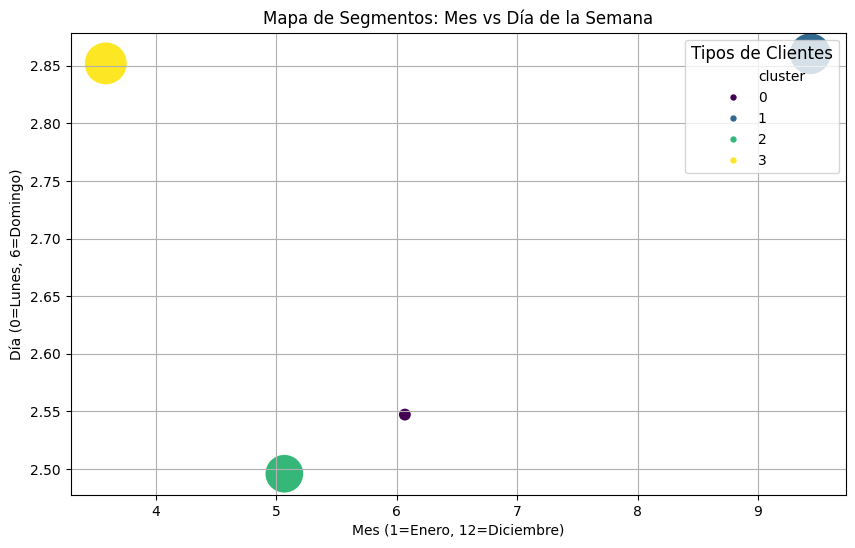

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_customer_profile, x='month', y='day_of_week', size='customers_count', hue="cluster", palette='viridis', sizes=(100, 1000), legend="full")
plt.title('Mapa de Segmentos: Mes vs Día de la Semana')
plt.xlabel('Mes (1=Enero, 12=Diciembre)')
plt.ylabel('Día (0=Lunes, 6=Domingo)')
plt.grid(True)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:5], labels[0:5], title='Tipos de Clientes', title_fontsize='12', loc='upper right')

#### Observaciones: 
> - La grafica presenta una distribucion de clusters bien diferenciada, indica que el número de clusters en los que se ha agrupado a los clientes es el correcto.
> - El primero grupo, `cluster 0`, de color morado representa a los clientes que efectuan compras sobre el mes de junio los martes. Sus compras mas recurrentes son:computers_accessories, watches_gifts y health_beauty. El gasto promedio es de 1336.66 R$
> - El Grupo minoritario en azul `cluster 1`, representa los clientes que suelen hacer compras en mayo los martes. Sus compras mas recurrentes son: health_beauty, bed_bath_table y sports_leisure. El gasto promedio es de 143.68 R$
> - `El cluster 2` en verde, representa los clientes que realizan compras en mayo los martes. Sus compras mas recurrentes son: bed_bath_table, health_beauty y sports_leisure. El gasto promedio es de 141.56 R$
> - Por último el `cluster 3` en amarillo representa los clientes que realizan compras a finales de febrero los martes. Sus compras mas recurrentes son: bed_bath_table, health_beauty y furniture_decor. El gasto promedio es de 143.97 R$

## Guardar datos

In [22]:
df.to_csv("../data/processed/olist_clustering.csv", index=False)
df_scaled.to_csv("../data/processed/olist_scaled_clustering.csv", index=False)